#### DataLake using DataFusion - Visualization !

In [5]:
from datafusion import SessionContext
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
import os
import plotly.express as px

#### Step 1 — Generate a Large Synthetic DatasetWe simulate an e-commerce dataset with millions of rows.

In [6]:
rows = 2_000_000
countries = ["US","India","UK","Germany","Canada"]
products = ["Laptop","Phone","Tablet","Monitor","Headphones"]
df = pd.DataFrame({    "order_id": np.arange(rows),    "country": np.random.choice(countries, rows),    "product": np.random.choice(products, rows),    "price": np.random.randint(50,1000,rows),    "quantity": np.random.randint(1,5,rows)})
df["sales"] = df["price"] * df["quantity"]
df.head()

,order_id,country,product,price,quantity,sales
0,0,UK,Phone,314,1,314
1,1,Germany,Tablet,423,4,1692
2,2,Germany,Headphones,396,2,792
3,3,India,Phone,467,3,1401
4,4,US,Monitor,788,3,2364


#### Step 2 — Write Data Lake Parquet FilesWe simulate a data lake layout with multiple Parquet files.

In [8]:
os.makedirs("lake/orders", exist_ok=True)

chunk_size = 200000
for i in range(0, len(df), chunk_size):
    chunk = df.iloc[i:i+chunk_size]
    table = pa.Table.from_pandas(chunk)
    pq.write_table(table, f"lake/orders/orders_{i}.parquet")

print("Parquet files written.")

Parquet files written.


#### Step 3 — Create DataFusion Session

In [9]:
ctx = SessionContext()

#### Step 4 — Register Data Lake DirectoryDataFusion can query multiple Parquet files as one dataset.

In [10]:
ctx.register_parquet("orders", "lake/orders/*.parquet")

#### Step 5 — Explore Dataset

In [11]:
ctx.sql("SELECT COUNT(*) as total_rows FROM orders").to_pandas()

,total_rows
0,2000000


#### Step 6 — Country Sales Analytics

In [12]:
country_sales = ctx.sql("""
    SELECT country, SUM(sales) AS total_sales 
    FROM orders
    GROUP BY country
""").to_pandas()

country_sales

,country,total_sales
0,US,525399287
1,India,524040301
2,Canada,524974661
3,UK,525011406
4,Germany,523413140


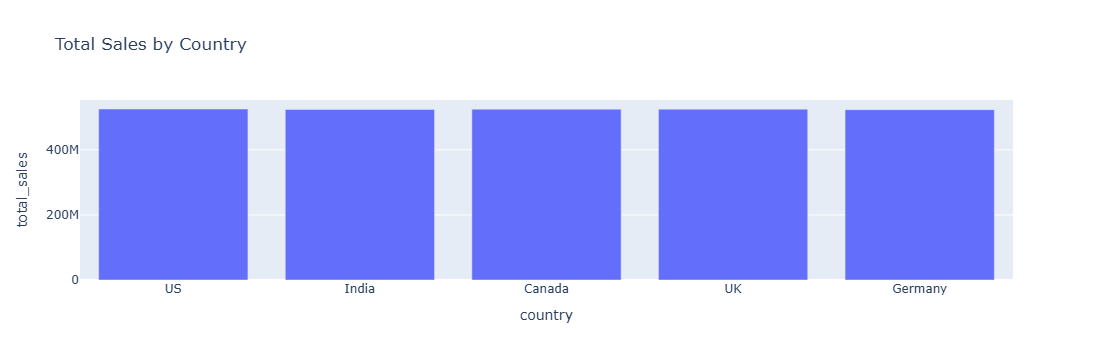

In [13]:
figure = px.bar(country_sales, x="country", y="total_sales", title="Total Sales by Country")
figure.show()

#### Step 7 — Product Analytics

In [15]:
product_sales = ctx.sql("""
    SELECT product,SUM(sales) as total_sales,COUNT(*) as orders 
    FROM orders 
    GROUP BY product
""").to_pandas()
product_sales

,product,total_sales,orders
0,Phone,524961018,399772
1,Tablet,524499274,399932
2,Laptop,524252381,399672
3,Monitor,524656365,400146
4,Headphones,524469757,400478


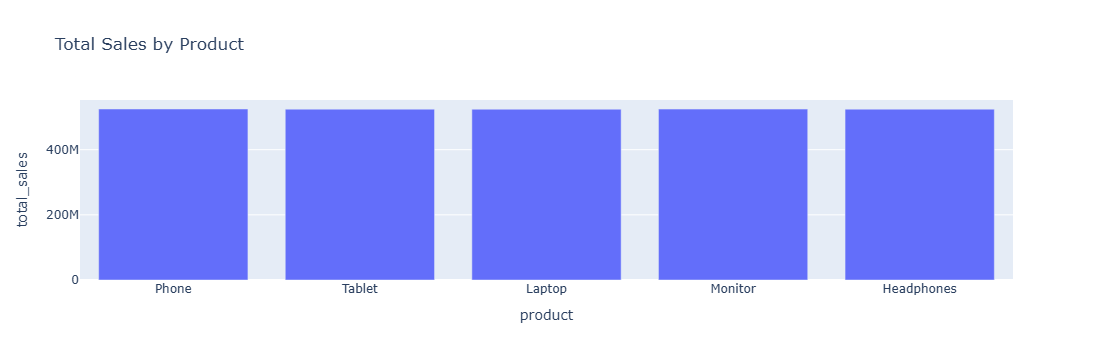

In [16]:
figure = px.bar(product_sales, x="product", y="total_sales", title="Total Sales by Product")
figure.show()

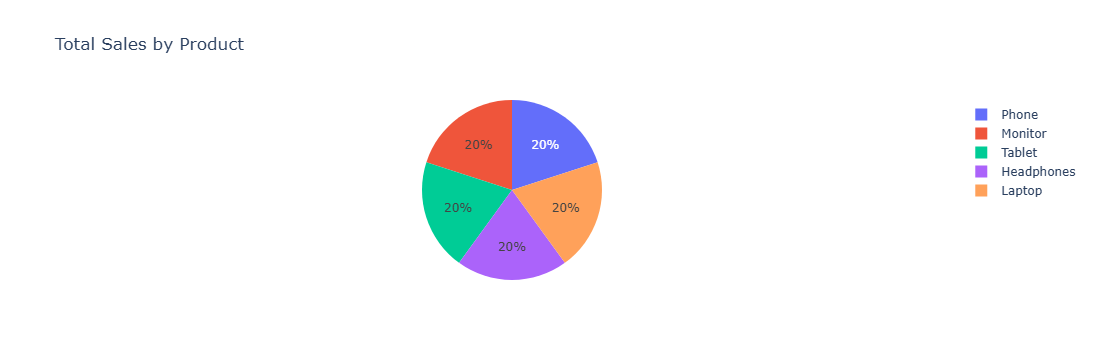

In [18]:
figure = px.pie(product_sales, values="total_sales", names="product", title="Total Sales by Product")
figure.show()

#### Step 8 — Advanced Analytical QueryExample of a more complex SQL query.

In [19]:
analytics = ctx.sql("""
    SELECT 
        country,
        product,
        SUM(sales) as total_sales,
        AVG(price) as avg_price,
        COUNT(*) as orders 
    FROM orders 
    GROUP BY country, product
""").to_pandas()
analytics.head()

,country,product,total_sales,avg_price,orders
0,UK,Laptop,105298550,526.002975,79998
1,UK,Phone,104737673,523.018205,79924
2,India,Laptop,104777425,523.442190,80219
3,Canada,Headphones,104725358,522.512694,80237
4,India,Phone,104685088,524.372130,79714


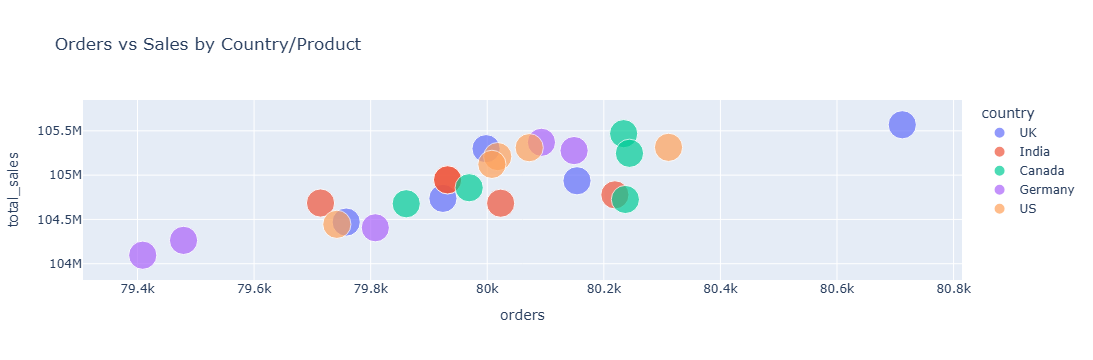

In [20]:
figure = px.scatter(analytics, x="orders", y="total_sales", color="country", size="avg_price", title="Orders vs Sales by Country/Product")
figure.show()

#### Step 9 — Query Execution Plan

In [ ]:
plan = ctx.sql("""
    SELECT 
        country, 
        SUM(sales)
    FROM orders 
    GROUP BY country
""")
print(plan.explain())